# Combined Model Chromatin Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
from src.chromatin_model import ChromatinModel


config1, config2 = load_config_from_replication_runs(
    'output/prototype_pipeline_subset/single_replication/', chrom=4)


Shifting mu0, gamma1, and gamma2, for alpha...


In [13]:
from src.combined_chromatin_model import CombinedChromatinModel
combined_model = CombinedChromatinModel(config1=config1, config2=config2)

In [73]:

chrom = 1
mnase_span = (20000, 20601)

combined_model.load_mnase_span(chrom, mnase_span)


Already loaded chromosome reads for 1. Using cache.
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading single replication profile g, 3/1/25
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 600) to (16, 26, 60)
Already loaded chromosome reads for 1. Using cache.
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading single replication profile g, 3/1/25
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 600) to (15, 26, 60)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(16, 251)
(15, 251)


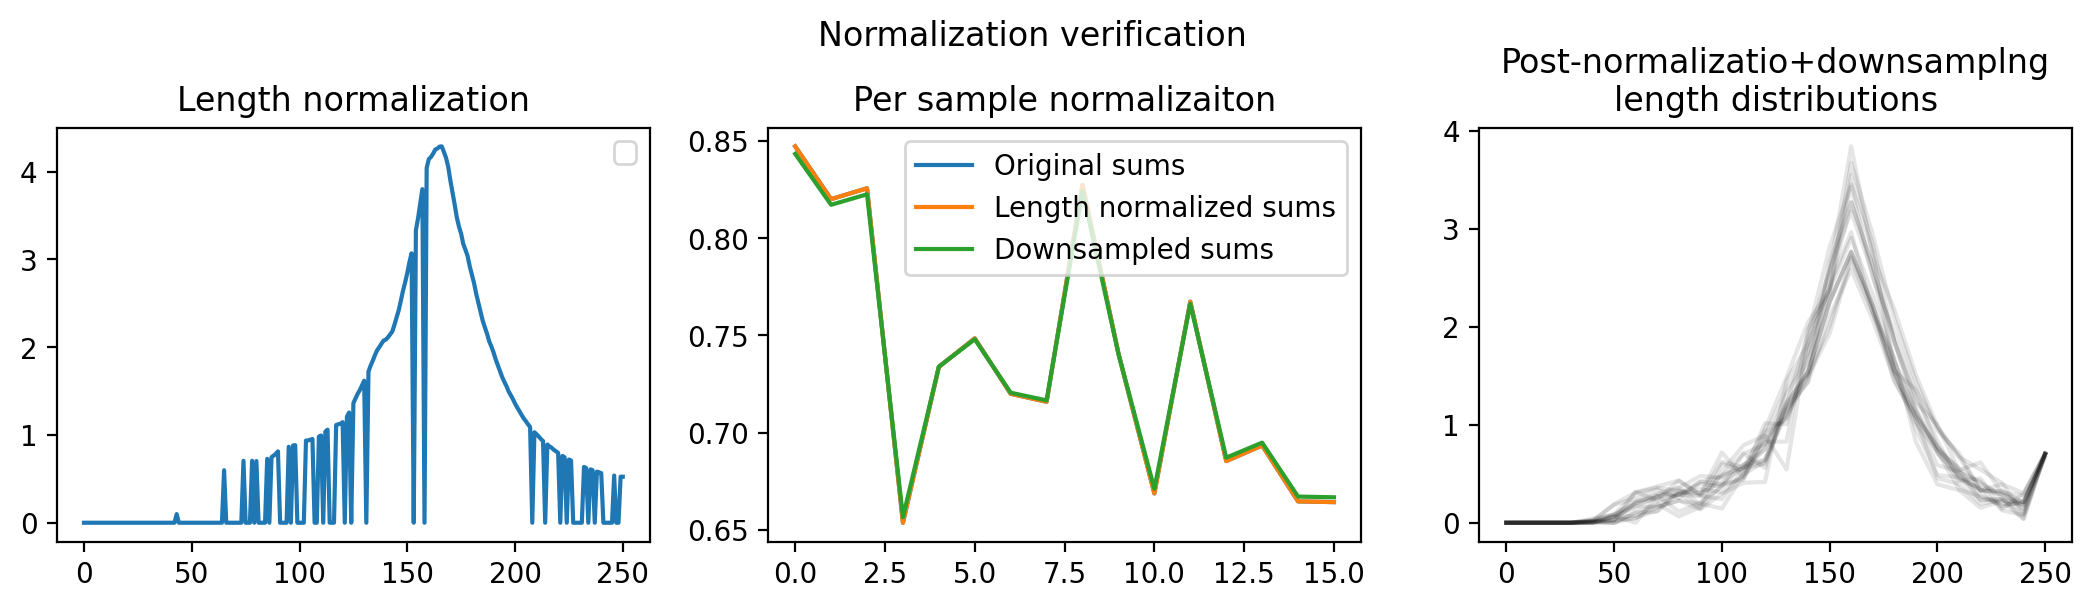

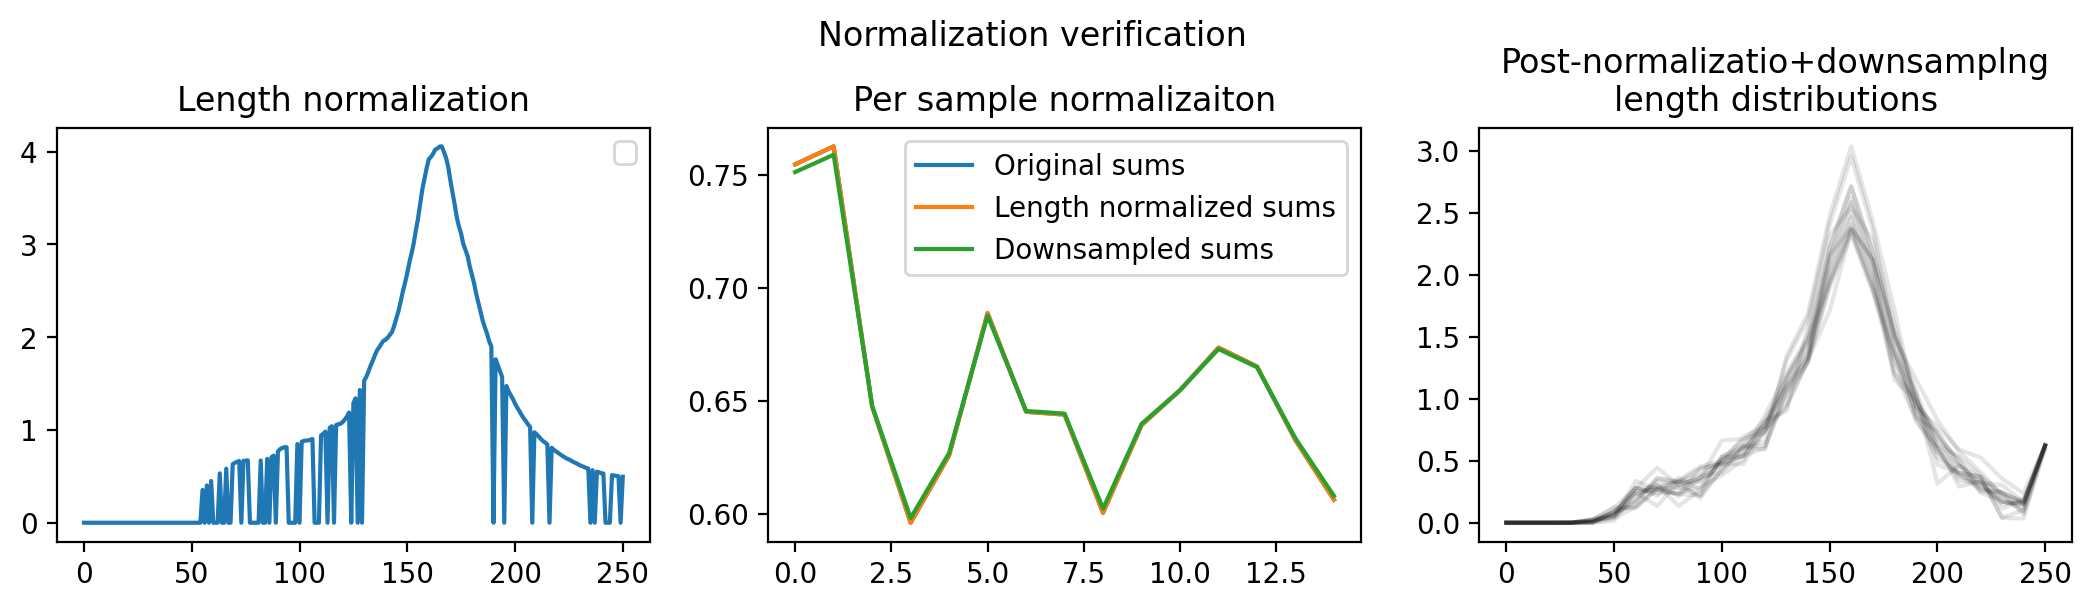

In [80]:
combined_model.chrom1_model.plot_normalization_sanity_check()
combined_model.chrom2_model.plot_normalization_sanity_check()

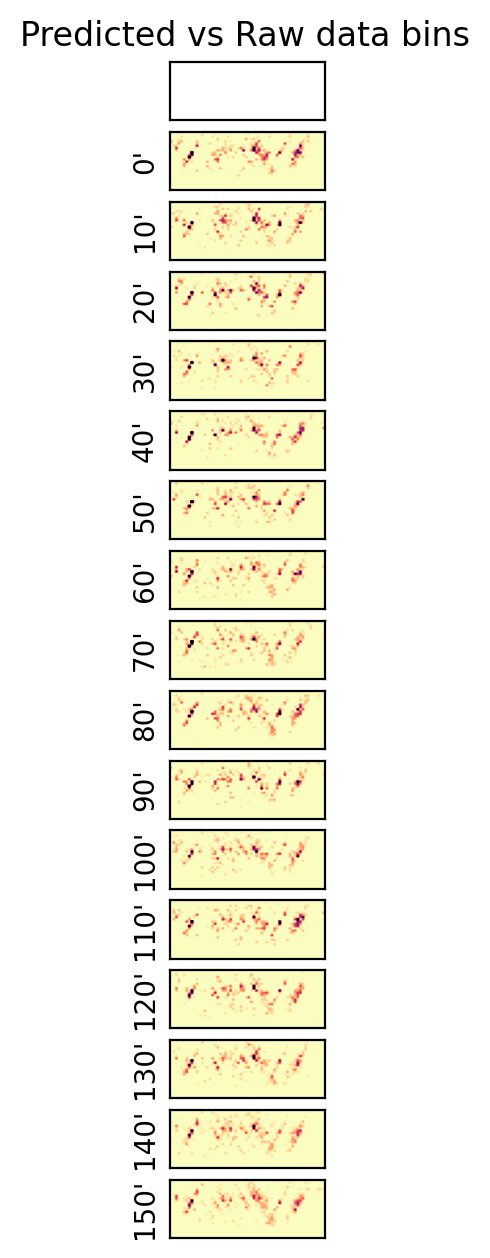

In [79]:
combined_model.chrom1_model.plot_raw_data(figsize=(1, 7))

In [133]:
combined_model.setup_deconv_model()

Loading single replication profile, 3/1/25
Trial N, need to use combined N curve
Loading single replication profile, 3/1/25
Trial N, need to use combined N curve
Adding a deconvolution offset to G: 1


In [135]:
combined_model.solver.deconvolve_G_iteratively(gamma=0.01, kappa=0, verbose=True)

0/1560 - 00:00:00.145
500/1560 - 00:01:06.802
1000/1560 - 00:02:17.222
1500/1560 - 00:03:27.187
Completed - 00:03:35.559


array([[ 67.28842106,  67.28842106,  67.28842106, ..., 127.99878308,
        127.84654955, 127.84654955],
       [ 67.28842228,  67.28842228,  67.28842228, ..., 127.99878489,
        127.84654251, 127.84654251],
       [ 67.28842356,  67.28842356,  67.28842356, ..., 127.99878679,
        127.84653512, 127.84653512],
       ...,
       [ 67.28844485,  67.28844485,  67.28844485, ..., 127.99881843,
        127.84641485, 127.84641485],
       [ 67.28844487,  67.28844487,  67.28844487, ..., 127.99881846,
        127.84641466, 127.84641466],
       [ 67.28842106,  67.28842106,  67.28842106, ..., 127.99878308,
        127.84654955, 127.84654955]])

In [163]:
G_testing = combined_model.G[:, 0:2]

In [164]:
combined_model.solver.G = G_testing

In [165]:
F_testing = combined_model.solver.deconvolve_G_iteratively(gamma=0.01, kappa=0, verbose=True)


0/2 - 00:00:00.142
Completed - 00:00:00.284


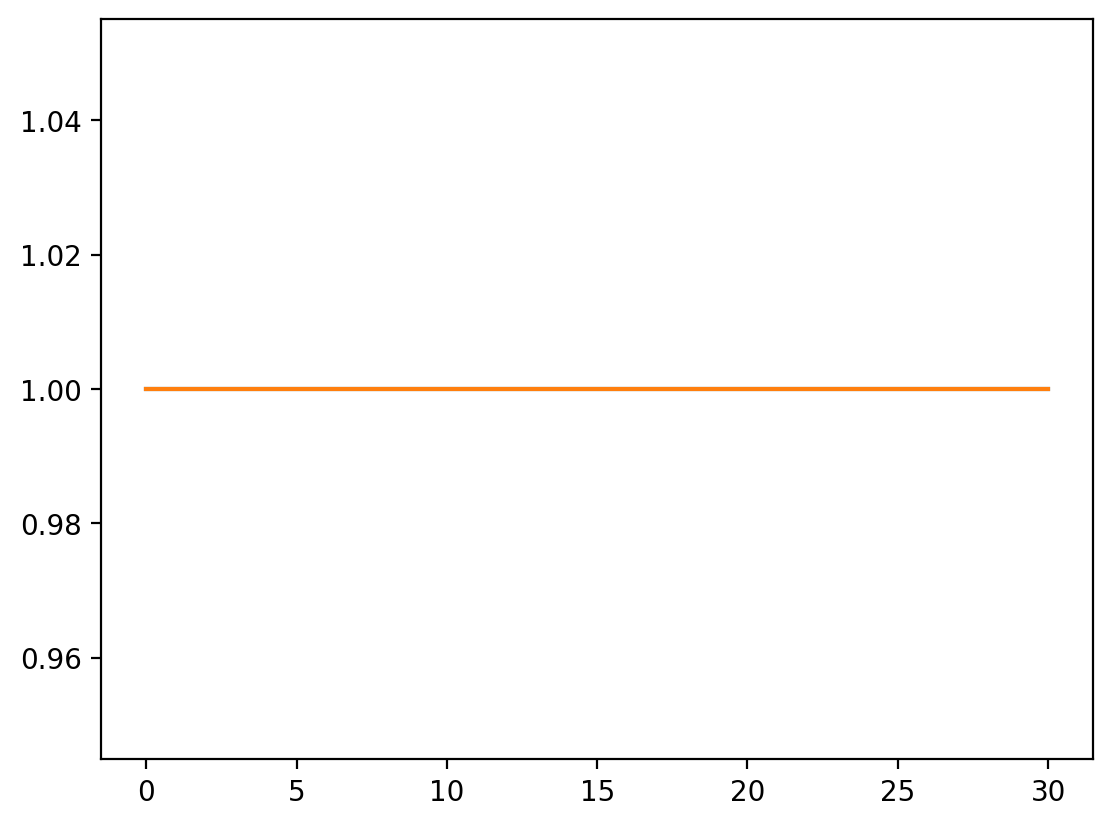

In [168]:
plt.plot(G_testing)

In [171]:
combined_model.f_replication

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 1.])

In [169]:
combined_model.b

0.8523454204799752

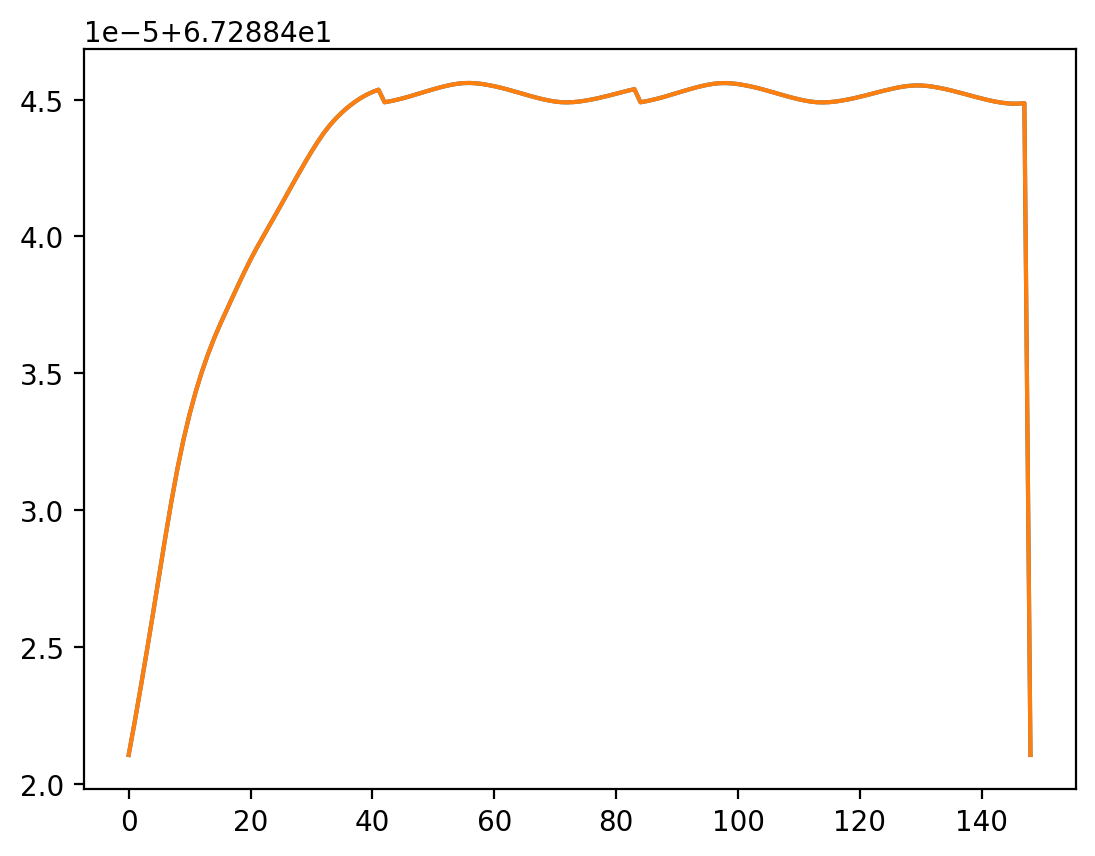

In [167]:
plt.plot(F_testing)

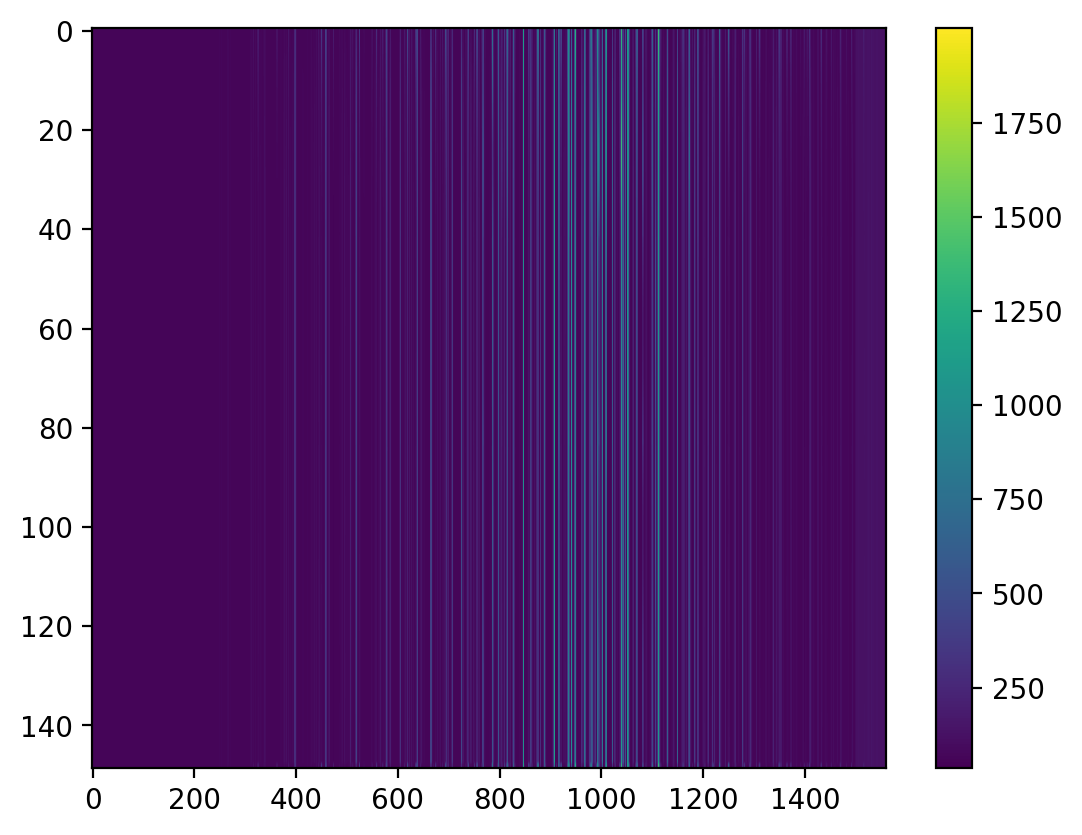

In [160]:
plt.imshow(combined_model.solver.F, aspect='auto')
plt.colorbar()

In [147]:
combined_model.plot_branches()

Error in callback <function _draw_all_if_interactive at 0x7fa8e8f47940> (for post_execute):


ValueError: minvalue must be less than or equal to maxvalue

ValueError: minvalue must be less than or equal to maxvalue

<Figure size 500x700 with 52 Axes>